<a href="https://colab.research.google.com/github/rubengamarro/practicas_aprendizaje_no_supervisado/blob/main/3_Redes_multicapa.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#EJERCICIO 1

In [337]:
import pandas as pd
import numpy as np

In [338]:
from sklearn.datasets import load_wine
data = load_wine()
X, y = data.data, data.target
X = pd.DataFrame(X, columns=data.feature_names)
X

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,13.71,5.65,2.45,20.5,95.0,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740.0
174,13.40,3.91,2.48,23.0,102.0,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750.0
175,13.27,4.28,2.26,20.0,120.0,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835.0
176,13.17,2.59,2.37,20.0,120.0,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840.0


In [339]:
for column in X.columns:
    print(f'{column}:\n Mínimo: {X[column].min()}, Máximo: {X[column].max()}')

alcohol:
 Mínimo: 11.03, Máximo: 14.83
malic_acid:
 Mínimo: 0.74, Máximo: 5.8
ash:
 Mínimo: 1.36, Máximo: 3.23
alcalinity_of_ash:
 Mínimo: 10.6, Máximo: 30.0
magnesium:
 Mínimo: 70.0, Máximo: 162.0
total_phenols:
 Mínimo: 0.98, Máximo: 3.88
flavanoids:
 Mínimo: 0.34, Máximo: 5.08
nonflavanoid_phenols:
 Mínimo: 0.13, Máximo: 0.66
proanthocyanins:
 Mínimo: 0.41, Máximo: 3.58
color_intensity:
 Mínimo: 1.28, Máximo: 13.0
hue:
 Mínimo: 0.48, Máximo: 1.71
od280/od315_of_diluted_wines:
 Mínimo: 1.27, Máximo: 4.0
proline:
 Mínimo: 278.0, Máximo: 1680.0


In [340]:
from sklearn.preprocessing import MinMaxScaler

#Normalizamos los datos
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

In [341]:
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

In [342]:
for column in X_scaled_df.columns:
    print(f'{column}:\n Mínimo: {X_scaled_df[column].min()}, Máximo: {X_scaled_df[column].max()}')

alcohol:
 Mínimo: 0.0, Máximo: 1.0
malic_acid:
 Mínimo: 0.0, Máximo: 1.0
ash:
 Mínimo: 0.0, Máximo: 0.9999999999999999
alcalinity_of_ash:
 Mínimo: 0.0, Máximo: 1.0
magnesium:
 Mínimo: 0.0, Máximo: 1.0
total_phenols:
 Mínimo: 0.0, Máximo: 1.0
flavanoids:
 Mínimo: 0.0, Máximo: 0.9999999999999998
nonflavanoid_phenols:
 Mínimo: 0.0, Máximo: 1.0
proanthocyanins:
 Mínimo: 0.0, Máximo: 0.9999999999999999
color_intensity:
 Mínimo: 0.0, Máximo: 0.9999999999999999
hue:
 Mínimo: 0.0, Máximo: 1.0
od280/od315_of_diluted_wines:
 Mínimo: 0.0, Máximo: 1.0
proline:
 Mínimo: 0.0, Máximo: 1.0


In [343]:
from sklearn.model_selection import train_test_split

#Dividimos los datos en entrenamiento y validación
X_ent, X_val, y_ent, y_val = train_test_split(X_scaled, y, test_size=0.2, stratify=y, random_state=10)

**Apartado b**

Introducimos las funciones y clases que necesitamos

In [344]:
import numpy as np

#Definición función logística simplificada,
#la general sería: 1. / (1. + np.exp(-2*Beta*h))
def logistica(h):
    g = 1. / (1. + np.exp(-h))
    return g

#Definición derivada de la función logística simplificada
#Ojo: Esta implementación recibe directamente el valor de la función a
#derivar g(h)
def derivada_logistica(g):
    g_prima = g * (1. - g)
    return g_prima

#Recibe un vector de enteros (salidas deseadas) y lo convierte en una matriz,
#una fila para cada salida deseada con un valor 1 en la posición de la salida deseada
def naturales_a_vectores(y, num_clases):
    matrizRes = np.zeros((y.shape[0], num_clases))

    #Iteramos por las salidas deseadas
    for i, val in enumerate(y):
        matrizRes[i, val] = 1
    return matrizRes

In [345]:
def generador_lotes(X, y, tam_lote):
    num_muestras = X.shape[0]
    # Vector con todos los indices del conjunto de muestras:
    indices = np.arange(num_muestras)
    # Ordenamos aleatoriamente los índices:
    np.random.shuffle(indices)
    # Creamos los índices que compondrán cada lote:
    for idx_muestra_inic_lote in range(0, num_muestras - tam_lote + 1, tam_lote):
        if idx_muestra_inic_lote + tam_lote > num_muestras:
            break  # Ignorar el último lote si es más pequeño que tam_lote
        indices_lote = \
          indices[idx_muestra_inic_lote:idx_muestra_inic_lote + tam_lote]
        # Devolvemos los rasgos y salidas deseadas del lote:
        yield X[indices_lote], y[indices_lote]
        #OjO: yield es parecido a return, pero no devuelve todos los valores,
        #sirve para crear un generador de objetos, conforme se van necesitando
        #más objetos, se van generando, por lo que no es necesario generarlos
        #todos si sólo usaremos algunos de ellos

In [346]:
class PrototipoRedMulticapa:
    # Constructor:
    def __init__(self, num_rasgos, num_ocultas,
                 num_clases, semilla=10):
        super().__init__()
        rng = np.random.RandomState(semilla)

        self.num_salidas = num_clases

        #################
        ## Capa oculta ##
        #################
        self.W1 = rng.normal(
            loc=0.0, scale=0.1, size=(num_ocultas, num_rasgos))
        self.sesgos1 = np.zeros(num_ocultas)

        #################
        ## Capa salida ##
        #################
        self.W2 = rng.normal(
            loc=0.0, scale=0.1, size=(self.num_salidas, num_ocultas))
        self.sesgos2 = np.zeros(self.num_salidas)

    # Calcula la salida de la red ante unos estímulos (lotes):
    def forward(self, X):
        # Dimensiones variables:
        # X -> [num_muestras x num_rasgos]

        #################
        ## Capa oculta ##
        #################

        # [num_muestras, num_ocultas] = [num_muestras x num_rasgos] · [num_ocultas, num_rasgos].T + [num_ocultas] "Se suman los sesgos en cada fila"
        pot_oculta = np.dot(X, self.W1.T) + self.sesgos1

        # [num_muestras, num_ocultas] = [num_muestras, num_ocultas]
        S = logistica(pot_oculta)

        #################
        ## Capa salida ##
        #################

        # [num_muestras, num_salidas] = [num_muestras, num_ocultas] · [num_salidas, num_ocultas].T + [num_salidas] "Se suman los sesgos en cada fila"
        pot_salida = np.dot(S, self.W2.T) + self.sesgos2

        # [num_muestras, num_salidas] = [num_muestras, num_salidas]
        y_predichas = logistica(pot_salida)

        return S, y_predichas

    # Calcula diferenciales de pesos sinápticos y sesgos
    # retropropagando el error (lotes):
    def backward(self, X, S, Y_pred, y_deseada):
        # Dimensiones variables:
        # X -> [num_muestras x num_rasgos] -> Rasgos
        # S -> [num_muestras x num_ocultas] -> Estados capa oculta
        # Y_pred -> [num_muestras x num_salidas] -> Matriz con salidas predichas
        # y_deseada -> [num_muestras x 1] -> Vector con salidas deseadas

        # [num_muestras x num_salidas] = [num_muestras x 1]
        Y_des = naturales_a_vectores(y_deseada, self.num_salidas)

        #################
        ## Capa salida ##
        #################

        # Valor escalar, "p" en los apuntes
        num_muestras = y_deseada.shape[0]

        # OJO: No es lo mismo el producto de matrices elemento a elemento "*"
        # que el producto escalar "np.dot(...)"

        # [num_muestras x num_salidas] = [num_muestras x num_salidas] * [num_muestras x num_salidas]
        delta_2 = (Y_des - Y_pred) / num_muestras * derivada_logistica(Y_pred)

        # [num_salidas x num_ocultas] = [num_muestras x num_salidas].T · [num_muestras x num_ocultas]
        dif_W2 = np.dot(delta_2.T, S)

        # [num_salidas] = [num_muestras x num_salidas]
        dif_sesgos2 = np.sum(delta_2, axis=0)

        #################
        ## Capa oculta ##
        #################

        # [num_muestras x num_ocultas] = [num_muestras x num_ocultas] * ([num_muestras x num_salidas] · [num_salidas x num_ocultas])
        delta_1 = derivada_logistica(S) * np.dot(delta_2, self.W2)

        # [num_ocultas x num_rasgos] = [num_muestras x num_ocultas].T · [num_muestras x num_rasgos]
        dif_W1 = np.dot(delta_1.T, X)

        # [num_ocultas] = [num_muestras x num_ocultas]
        dif_sesgos1 = np.sum(delta_1, axis=0)

        return (dif_W2, dif_sesgos2,
                dif_W1, dif_sesgos1)

In [347]:
# Calcula ECM de un lote
def calcula_ECM(y_deseadas, prob_salidas):
    #Formato de entrada: [num_muestras x num_clases]
    return np.mean((y_deseadas - prob_salidas)**2)

# Calcula exactitud de un lote
def calcula_exactitud(clases_deseadas, clases_pred):
    #Formato de entrada: [num_muestras]
    return np.mean(clases_deseadas == clases_pred)

In [348]:
# Calcula ECM y exactitud de un conjunto de muestras para una red neuronal
# Divide los cálculos lote a lote para evitar problemas de memoria
def calcular_ecm_exactitud(redNeuronal, X, y, num_clases, tam_lote=100):
    ecm_total, exact_total, num_lotes = 0., 0., 0

    gen_lotes = generador_lotes(X, y, tam_lote)
    for (X_lote, y_deseadas_lote) in gen_lotes:
        # [tam_lote x num_clases] = ...
        _, Prob_salidas = redNeuronal.forward(X_lote)

        # Para cada muestra, obtenemos la posición de la componente de mayor probabilidad
        # [tam_lote] = ...
        clases_pred = np.argmax(Prob_salidas, axis=1)
        exact_total += calcula_exactitud(y_deseadas_lote, clases_pred)

        # Construimos una matriz donde cada fila es un vector de componentes deseadas
        # [tam_lote x num_clases] = ...
        Clases_des = naturales_a_vectores(y_deseadas_lote, num_clases)
        ecm_total += calcula_ECM(Clases_des, Prob_salidas)

        num_lotes += 1

    ecm_total = ecm_total/num_lotes
    exact_total = exact_total/num_lotes

    return ecm_total, exact_total

In [349]:
class RedMulticapa(PrototipoRedMulticapa):

    def entrenar(self, X_ent, y_ent, X_val, y_val, num_epocas=10,
                 tasa_aprend=0.1, tam_lote=100):
        ecm_ent_epocas, exact_ent_epocas, exact_val_epocas = [], [], []

        # Iteramos sobre las épocas
        for idx_epoca in range(num_epocas):
            # Iteramos sobre los lotes
            gen_lotes = generador_lotes(X_ent, y_ent, tam_lote)
            for X_ent_lote, y_ent_lote in gen_lotes:
                #### Calcular salidas ####
                S, y_pred = self.forward(X_ent_lote)

                #### Calcular diferenciales de pesos y sesgos ####
                dif_W2, dif_sesgos2, dif_W1, dif_sesgos1 = \
                    self.backward(X_ent_lote, S, y_pred, y_ent_lote)

                #### Actualización de pesos ####
                self.W1 += tasa_aprend * dif_W1
                self.sesgos1 += tasa_aprend * dif_sesgos1
                self.W2 += tasa_aprend * dif_W2
                self.sesgos2 += tasa_aprend * dif_sesgos2

            #### Anotamos rendimientos al finalizar época ####
            ecm_ent, exact_ent = calcular_ecm_exactitud(
                self, X_ent, y_ent, self.num_salidas, tam_lote)
            ecm_val, exact_val = calcular_ecm_exactitud(
                self, X_val, y_val, self.num_salidas, tam_lote)

            exact_ent = exact_ent*100
            exact_val = exact_val*100
            exact_ent_epocas.append(exact_ent)
            exact_val_epocas.append(exact_val)
            ecm_ent_epocas.append(ecm_ent)
            print(f'Época: {idx_epoca+1:03d}/{num_epocas:03d} '
                  f'| ECM entrenamiento: {ecm_ent:.2f} '
                  f'| Exact entrenamiento: {exact_ent:.2f}% '
                  f'| Exact Validación: {exact_val:.2f}%')

        return ecm_ent_epocas, exact_ent_epocas, exact_val_epocas

Creamos la red multicapa

In [350]:
redMLP = RedMulticapa(num_rasgos=13,
                      num_ocultas=40,
                      num_clases=3)

Entrenamos el modelo

In [351]:
np.random.seed(10)
ecm_ent_epocas, exact_ent_epocas, exact_val_epocas = redMLP.entrenar(
    X_ent, y_ent, X_val, y_val, num_epocas=30, tasa_aprend=0.3, tam_lote=5)

Época: 001/030 | ECM entrenamiento: 0.22 | Exact entrenamiento: 40.00% | Exact Validación: 40.00%
Época: 002/030 | ECM entrenamiento: 0.22 | Exact entrenamiento: 40.71% | Exact Validación: 40.00%
Época: 003/030 | ECM entrenamiento: 0.22 | Exact entrenamiento: 40.00% | Exact Validación: 37.14%
Época: 004/030 | ECM entrenamiento: 0.21 | Exact entrenamiento: 40.71% | Exact Validación: 40.00%
Época: 005/030 | ECM entrenamiento: 0.21 | Exact entrenamiento: 68.57% | Exact Validación: 68.57%
Época: 006/030 | ECM entrenamiento: 0.21 | Exact entrenamiento: 40.00% | Exact Validación: 40.00%
Época: 007/030 | ECM entrenamiento: 0.21 | Exact entrenamiento: 40.71% | Exact Validación: 37.14%
Época: 008/030 | ECM entrenamiento: 0.21 | Exact entrenamiento: 40.71% | Exact Validación: 37.14%
Época: 009/030 | ECM entrenamiento: 0.21 | Exact entrenamiento: 40.00% | Exact Validación: 40.00%
Época: 010/030 | ECM entrenamiento: 0.20 | Exact entrenamiento: 40.71% | Exact Validación: 40.00%
Época: 011/030 | ECM

**Apartado c**

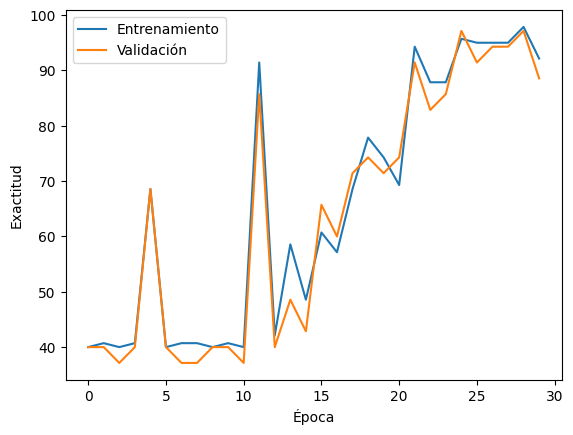

In [352]:
from matplotlib import pyplot as plt

plt.plot(range(len(exact_ent_epocas)), exact_ent_epocas,
         label='Entrenamiento')
plt.plot(range(len(exact_val_epocas)), exact_val_epocas,
         label='Validación')
plt.ylabel('Exactitud')
plt.xlabel('Época')
plt.legend(loc='best')
plt.show()

Podemos ver como hasta la época 10-15 el modelo está subajustado pero a partir de ahí el modelo clasifica bien. A partir de las 25-30 épocas vemos como el modelo llega a un máximo de exactitud y empieza a estabilizarse e incluso a decaer, lo que puede significar un poco de sobreajuste a partir de 30 épocas.

**Apartado d**

In [353]:
_, prob_salidas = redMLP.forward(X_val)
val_pred = np.argmax(prob_salidas, axis=1)

In [354]:
print("\nMuestras mal clasificadas:")
for i in range(len(y_val)):
    if val_pred[i] != y_val[i]:
        print(f"\nMuestra: {i}")
        print(f"Clase deseada: {y_val[i]}")
        print(f"Clase predicha: {val_pred[i]}")
        print(f"Probabilidades: {prob_salidas[i]}")


Muestras mal clasificadas:

Muestra: 10
Clase deseada: 1
Clase predicha: 2
Probabilidades: [0.18705643 0.37091645 0.43676557]

Muestra: 13
Clase deseada: 1
Clase predicha: 0
Probabilidades: [0.611096   0.44781507 0.07745454]

Muestra: 23
Clase deseada: 1
Clase predicha: 0
Probabilidades: [0.52109651 0.44570163 0.10835312]

Muestra: 27
Clase deseada: 1
Clase predicha: 0
Probabilidades: [0.57002829 0.47241237 0.08450357]


#EJERCICIO 2

In [355]:
from sklearn.datasets import fetch_olivetti_faces
data = fetch_olivetti_faces()
X, y = data.data, data.target
X = pd.DataFrame(X, columns=[f'Pixel {i+1}' for i in range(X.shape[1])])
X

,Pixel 1,Pixel 2,Pixel 3,Pixel 4,Pixel 5,Pixel 6,Pixel 7,Pixel 8,Pixel 9,Pixel 10,...,Pixel 4087,Pixel 4088,Pixel 4089,Pixel 4090,Pixel 4091,Pixel 4092,Pixel 4093,Pixel 4094,Pixel 4095,Pixel 4096
0,0.309917,0.367769,0.417355,0.442149,0.528926,0.607438,0.657025,0.677686,0.690083,0.685950,...,0.665289,0.669421,0.652893,0.661157,0.475207,0.132231,0.148760,0.152893,0.161157,0.157025
1,0.454545,0.471074,0.512397,0.557851,0.595041,0.640496,0.681818,0.702479,0.710744,0.702479,...,0.136364,0.157025,0.136364,0.148760,0.152893,0.152893,0.152893,0.152893,0.152893,0.152893
2,0.318182,0.400826,0.491736,0.528926,0.586777,0.657025,0.681818,0.685950,0.702479,0.698347,...,0.074380,0.132231,0.181818,0.136364,0.128099,0.148760,0.144628,0.140496,0.148760,0.152893
3,0.198347,0.194215,0.194215,0.194215,0.190083,0.190083,0.243802,0.404959,0.483471,0.516529,...,0.652893,0.636364,0.657025,0.685950,0.727273,0.743802,0.764463,0.752066,0.752066,0.739669
4,0.500000,0.545455,0.582645,0.623967,0.648760,0.690083,0.694215,0.714876,0.723140,0.731405,...,0.190083,0.161157,0.177686,0.173554,0.177686,0.177686,0.177686,0.177686,0.173554,0.173554
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
395,0.400826,0.495868,0.570248,0.632231,0.648760,0.640496,0.661157,0.636364,0.665289,0.698347,...,0.388430,0.396694,0.264463,0.099174,0.181818,0.243802,0.247934,0.161157,0.157025,0.136364
396,0.367769,0.367769,0.351240,0.301653,0.247934,0.247934,0.367769,0.512397,0.574380,0.628099,...,0.380165,0.334711,0.289256,0.285124,0.338843,0.404959,0.458678,0.487603,0.512397,0.549587
397,0.500000,0.533058,0.607438,0.628099,0.657025,0.632231,0.657025,0.669421,0.673554,0.702479,...,0.194215,0.148760,0.152893,0.161157,0.161157,0.173554,0.157025,0.177686,0.148760,0.190083
398,0.214876,0.219008,0.219008,0.223140,0.210744,0.202479,0.276859,0.400826,0.487603,0.549587,...,0.446281,0.392562,0.367769,0.409091,0.479339,0.524793,0.545455,0.574380,0.590909,0.603306


In [356]:
altoDigito, anchoDigito = 64, 64

**Apartado a**

In [357]:
from sklearn.preprocessing import StandardScaler

#Normalizamos los datos
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [358]:
from sklearn.model_selection import train_test_split

#Dividimos los datos en entrenamiento y validación
X_ent, X_val, y_ent, y_val = train_test_split(X_scaled, y, test_size=0.2, stratify=y, random_state=10)

**Apartado b**

In [359]:
redMLP2 = RedMulticapa(num_rasgos=altoDigito*anchoDigito,
                      num_ocultas=100,
                      num_clases=40)

In [360]:
np.random.seed(10)
ecm_ent_epocas1, exact_ent_epocas1, exact_val_epocas1 = redMLP2.entrenar(
    X_ent, y_ent, X_val, y_val, num_epocas=200, tasa_aprend=0.2, tam_lote=16)

Época: 001/200 | ECM entrenamiento: 0.03 | Exact entrenamiento: 13.75% | Exact Validación: 10.00%
Época: 002/200 | ECM entrenamiento: 0.02 | Exact entrenamiento: 25.31% | Exact Validación: 16.25%
Época: 003/200 | ECM entrenamiento: 0.02 | Exact entrenamiento: 33.75% | Exact Validación: 21.25%
Época: 004/200 | ECM entrenamiento: 0.02 | Exact entrenamiento: 39.69% | Exact Validación: 26.25%
Época: 005/200 | ECM entrenamiento: 0.02 | Exact entrenamiento: 43.75% | Exact Validación: 32.50%
Época: 006/200 | ECM entrenamiento: 0.02 | Exact entrenamiento: 46.88% | Exact Validación: 41.25%
Época: 007/200 | ECM entrenamiento: 0.02 | Exact entrenamiento: 49.06% | Exact Validación: 45.00%
Época: 008/200 | ECM entrenamiento: 0.02 | Exact entrenamiento: 51.88% | Exact Validación: 46.25%
Época: 009/200 | ECM entrenamiento: 0.02 | Exact entrenamiento: 55.00% | Exact Validación: 48.75%
Época: 010/200 | ECM entrenamiento: 0.02 | Exact entrenamiento: 57.81% | Exact Validación: 50.00%
Época: 011/200 | ECM

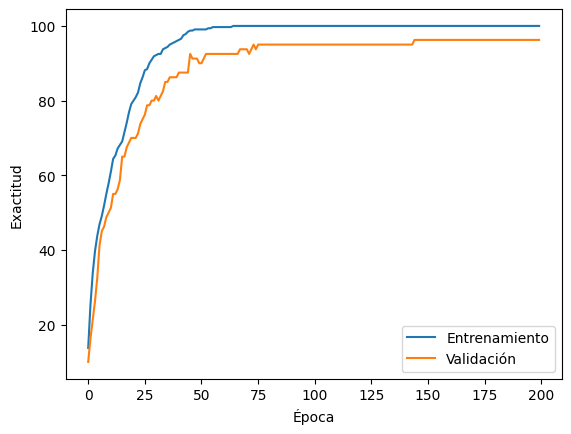

In [361]:
from matplotlib import pyplot as plt

plt.plot(range(len(exact_ent_epocas1)), exact_ent_epocas1,
         label='Entrenamiento')
plt.plot(range(len(exact_val_epocas1)), exact_val_epocas1,
         label='Validación')
plt.ylabel('Exactitud')
plt.xlabel('Época')
plt.legend(loc='best')
plt.show()

**Apartado c**

In [362]:
redMLP3 = RedMulticapa(num_rasgos=altoDigito*anchoDigito,
                      num_ocultas=10,
                      num_clases=40)

In [363]:
np.random.seed(10)
ecm_ent_epocas2, exact_ent_epocas2, exact_val_epocas2 = redMLP3.entrenar(
    X_ent, y_ent, X_val, y_val, num_epocas=200, tasa_aprend=0.2, tam_lote=16)

Época: 001/200 | ECM entrenamiento: 0.07 | Exact entrenamiento: 0.62% | Exact Validación: 1.25%
Época: 002/200 | ECM entrenamiento: 0.04 | Exact entrenamiento: 4.06% | Exact Validación: 5.00%
Época: 003/200 | ECM entrenamiento: 0.04 | Exact entrenamiento: 6.88% | Exact Validación: 12.50%
Época: 004/200 | ECM entrenamiento: 0.03 | Exact entrenamiento: 6.56% | Exact Validación: 10.00%
Época: 005/200 | ECM entrenamiento: 0.03 | Exact entrenamiento: 8.12% | Exact Validación: 10.00%
Época: 006/200 | ECM entrenamiento: 0.03 | Exact entrenamiento: 11.88% | Exact Validación: 8.75%
Época: 007/200 | ECM entrenamiento: 0.03 | Exact entrenamiento: 12.19% | Exact Validación: 10.00%
Época: 008/200 | ECM entrenamiento: 0.03 | Exact entrenamiento: 13.44% | Exact Validación: 11.25%
Época: 009/200 | ECM entrenamiento: 0.03 | Exact entrenamiento: 14.69% | Exact Validación: 12.50%
Época: 010/200 | ECM entrenamiento: 0.03 | Exact entrenamiento: 14.69% | Exact Validación: 15.00%
Época: 011/200 | ECM entrena

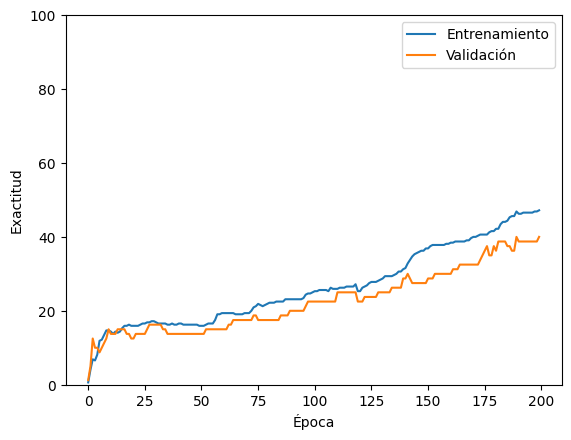

In [364]:
from matplotlib import pyplot as plt

plt.plot(range(len(exact_ent_epocas2)), exact_ent_epocas2,
         label='Entrenamiento')
plt.plot(range(len(exact_val_epocas2)), exact_val_epocas2,
         label='Validación')
plt.ylabel('Exactitud')
plt.xlabel('Época')
plt.ylim(0, 100)
plt.legend(loc='best')
plt.show()

**Apartado d**

In [365]:
redMLP4 = RedMulticapa(num_rasgos=altoDigito*anchoDigito,
                      num_ocultas=100,
                      num_clases=40)

In [366]:
np.random.seed(10)
ecm_ent_epocas3, exact_ent_epocas3, exact_val_epocas3 = redMLP4.entrenar(
    X_ent, y_ent, X_val, y_val, num_epocas=200, tasa_aprend=0.02, tam_lote=16)

Época: 001/200 | ECM entrenamiento: 0.11 | Exact entrenamiento: 4.69% | Exact Validación: 5.00%
Época: 002/200 | ECM entrenamiento: 0.06 | Exact entrenamiento: 5.94% | Exact Validación: 7.50%
Época: 003/200 | ECM entrenamiento: 0.05 | Exact entrenamiento: 6.25% | Exact Validación: 8.75%
Época: 004/200 | ECM entrenamiento: 0.04 | Exact entrenamiento: 7.19% | Exact Validación: 8.75%
Época: 005/200 | ECM entrenamiento: 0.04 | Exact entrenamiento: 8.75% | Exact Validación: 8.75%
Época: 006/200 | ECM entrenamiento: 0.03 | Exact entrenamiento: 9.38% | Exact Validación: 10.00%
Época: 007/200 | ECM entrenamiento: 0.03 | Exact entrenamiento: 10.94% | Exact Validación: 10.00%
Época: 008/200 | ECM entrenamiento: 0.03 | Exact entrenamiento: 11.56% | Exact Validación: 10.00%
Época: 009/200 | ECM entrenamiento: 0.03 | Exact entrenamiento: 13.75% | Exact Validación: 10.00%
Época: 010/200 | ECM entrenamiento: 0.03 | Exact entrenamiento: 15.31% | Exact Validación: 13.75%
Época: 011/200 | ECM entrenamie

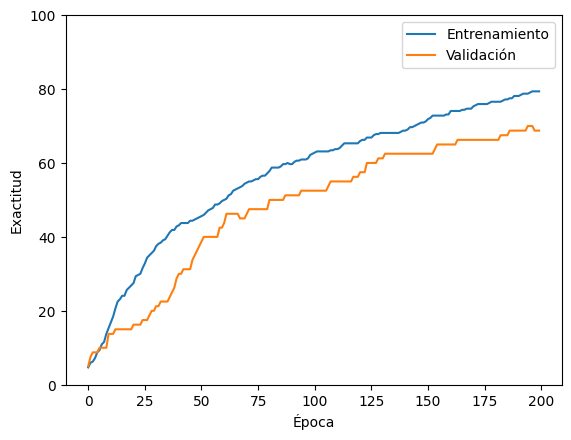

In [367]:
from matplotlib import pyplot as plt

plt.plot(range(len(exact_ent_epocas3)), exact_ent_epocas3,
         label='Entrenamiento')
plt.plot(range(len(exact_val_epocas3)), exact_val_epocas3,
         label='Validación')
plt.ylabel('Exactitud')
plt.xlabel('Época')
plt.ylim(0, 100)
plt.legend(loc='best')
plt.show()

**Apartado e**

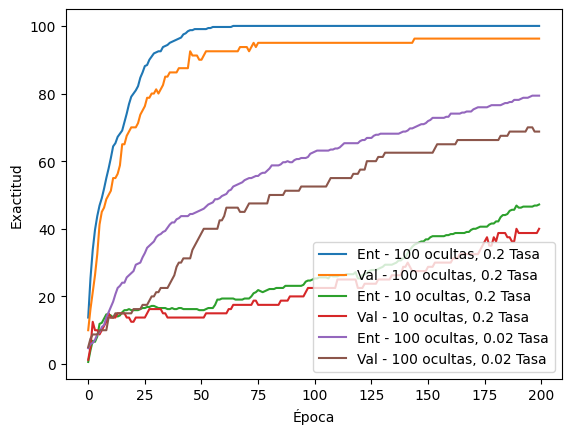

In [368]:
plt.plot(range(len(exact_ent_epocas1)), exact_ent_epocas1, label='Ent - 100 ocultas, 0.2 Tasa')
plt.plot(range(len(exact_val_epocas1)), exact_val_epocas1, label='Val - 100 ocultas, 0.2 Tasa')
plt.plot(range(len(exact_ent_epocas2)), exact_ent_epocas2, label='Ent - 10 ocultas, 0.2 Tasa')
plt.plot(range(len(exact_val_epocas2)), exact_val_epocas2, label='Val - 10 ocultas, 0.2 Tasa')
plt.plot(range(len(exact_ent_epocas3)), exact_ent_epocas3, label='Ent - 100 ocultas, 0.02 Tasa')
plt.plot(range(len(exact_val_epocas3)), exact_val_epocas3, label='Val - 100 ocultas, 0.02 Tasa')

plt.ylabel('Exactitud')
plt.xlabel('Época')
plt.legend(loc='best')
plt.show()

**Apartado f**

El primer modelo con 100 neuronas ocultas y una tasa de aprendizaje de 0.2 obtiene muy buenos resultados llegando al 95% de exactitud en 100 épocas de entrenamiento porque tiene suficiente capacidad (100 neuronas) para capturar las 4096 características del conjunto de datos. Sin embargo, para el modelo con 10 neuronas ocultas podemos ver como obtenemos una exactitud muy baja, esto se debe a que el modelo tiene una capacidad muy limitada con tan solo 10 neuronas y se produce un claro subajuste. Por otro lado, el modelo con 100 neuronas ocultas y tasa de aprendizaje 0.02, tiene la capacidad suficiente con las 100 neuronas ocultas, pero los pasos más pequeños en la actualización de pesos hacen que las curvas de exactitud suban más lentamente.

**Apartado g**

El modelo con solo 10 neuronas seguramente no alcance la exactitud de 95%, ya que aunque aumentemos el número de epocas, este modelo no tiene la capacidad suficiente, por lo que se seguirá produciendo un subajuste. Por otro lado, el modelo con 100 neuronas ocultas y tasa de aprendizaje 0.02, seguramente sí que alcance el 95% al aumentar el número de épocas, ya que tiene una convergencia lenta al tener una pequeña tasa de aprendizaje, pero al aumentar el números de épocas seguramente lo alcance. Veámoslo:

In [369]:
redMLP5 = RedMulticapa(num_rasgos=altoDigito*anchoDigito,
                      num_ocultas=100,
                      num_clases=40)

In [370]:
np.random.seed(10)
ecm_ent_epocas4, exact_ent_epocas4, exact_val_epocas4 = redMLP5.entrenar(
    X_ent, y_ent, X_val, y_val, num_epocas=700, tasa_aprend=0.02, tam_lote=16)

Época: 001/700 | ECM entrenamiento: 0.11 | Exact entrenamiento: 4.69% | Exact Validación: 5.00%
Época: 002/700 | ECM entrenamiento: 0.06 | Exact entrenamiento: 5.94% | Exact Validación: 7.50%
Época: 003/700 | ECM entrenamiento: 0.05 | Exact entrenamiento: 6.25% | Exact Validación: 8.75%
Época: 004/700 | ECM entrenamiento: 0.04 | Exact entrenamiento: 7.19% | Exact Validación: 8.75%
Época: 005/700 | ECM entrenamiento: 0.04 | Exact entrenamiento: 8.75% | Exact Validación: 8.75%
Época: 006/700 | ECM entrenamiento: 0.03 | Exact entrenamiento: 9.38% | Exact Validación: 10.00%
Época: 007/700 | ECM entrenamiento: 0.03 | Exact entrenamiento: 10.94% | Exact Validación: 10.00%
Época: 008/700 | ECM entrenamiento: 0.03 | Exact entrenamiento: 11.56% | Exact Validación: 10.00%
Época: 009/700 | ECM entrenamiento: 0.03 | Exact entrenamiento: 13.75% | Exact Validación: 10.00%
Época: 010/700 | ECM entrenamiento: 0.03 | Exact entrenamiento: 15.31% | Exact Validación: 13.75%
Época: 011/700 | ECM entrenamie

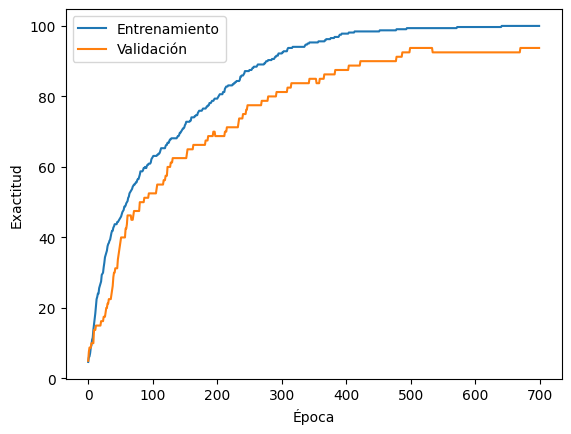

In [371]:
from matplotlib import pyplot as plt

plt.plot(range(len(exact_ent_epocas4)), exact_ent_epocas4,
         label='Entrenamiento')
plt.plot(range(len(exact_val_epocas4)), exact_val_epocas4,
         label='Validación')
plt.ylabel('Exactitud')
plt.xlabel('Época')
plt.legend(loc='best')
plt.show()

#EJERCICIO 3

In [432]:
from sklearn.datasets import load_breast_cancer
dataset = load_breast_cancer()
X = dataset.data
y = dataset.target
X = pd.DataFrame(X, columns=dataset.feature_names)
X

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


**Apartado a**

In [433]:
from sklearn.preprocessing import StandardScaler

#Normalizamos los datos
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [434]:
from sklearn.model_selection import train_test_split

#Dividimos los datos en entrenamiento y validación
X_ent, X_val, y_ent, y_val = train_test_split(X_scaled, y, test_size=0.2, stratify=y, random_state=10)

**Apartado b**

In [435]:
num_ocultas = [1, 2, 4, 8, 16, 32, 64, 128]

for n in num_ocultas:
    globals()[f'redMLP_{n}'] = RedMulticapa(num_rasgos=30,
                                            num_ocultas=n,
                                            num_clases=2)

Red multicapa con 1 neurona oculta:

In [436]:
np.random.seed(10)
ecm_ent_epocas_1, exact_ent_epocas_1, exact_val_epocas_1 = redMLP_1.entrenar(
    X_ent, y_ent, X_val, y_val, num_epocas=100, tasa_aprend=0.05, tam_lote=16)

Época: 001/100 | ECM entrenamiento: 0.25 | Exact entrenamiento: 62.50% | Exact Validación: 63.39%
Época: 002/100 | ECM entrenamiento: 0.25 | Exact entrenamiento: 62.95% | Exact Validación: 63.39%
Época: 003/100 | ECM entrenamiento: 0.24 | Exact entrenamiento: 62.72% | Exact Validación: 62.50%
Época: 004/100 | ECM entrenamiento: 0.24 | Exact entrenamiento: 62.05% | Exact Validación: 63.39%
Época: 005/100 | ECM entrenamiento: 0.24 | Exact entrenamiento: 62.95% | Exact Validación: 62.50%
Época: 006/100 | ECM entrenamiento: 0.24 | Exact entrenamiento: 62.28% | Exact Validación: 63.39%
Época: 007/100 | ECM entrenamiento: 0.24 | Exact entrenamiento: 62.50% | Exact Validación: 64.29%
Época: 008/100 | ECM entrenamiento: 0.24 | Exact entrenamiento: 62.95% | Exact Validación: 63.39%
Época: 009/100 | ECM entrenamiento: 0.24 | Exact entrenamiento: 62.72% | Exact Validación: 63.39%
Época: 010/100 | ECM entrenamiento: 0.24 | Exact entrenamiento: 62.50% | Exact Validación: 62.50%
Época: 011/100 | ECM

Red multicapa con 2 neuronas ocultas:

In [437]:
np.random.seed(10)
ecm_ent_epocas_2, exact_ent_epocas_2, exact_val_epocas_2 = redMLP_2.entrenar(
    X_ent, y_ent, X_val, y_val, num_epocas=100, tasa_aprend=0.05, tam_lote=16)

Época: 001/100 | ECM entrenamiento: 0.25 | Exact entrenamiento: 62.50% | Exact Validación: 63.39%
Época: 002/100 | ECM entrenamiento: 0.24 | Exact entrenamiento: 62.95% | Exact Validación: 63.39%
Época: 003/100 | ECM entrenamiento: 0.24 | Exact entrenamiento: 62.72% | Exact Validación: 62.50%
Época: 004/100 | ECM entrenamiento: 0.24 | Exact entrenamiento: 62.05% | Exact Validación: 63.39%
Época: 005/100 | ECM entrenamiento: 0.24 | Exact entrenamiento: 62.95% | Exact Validación: 62.50%
Época: 006/100 | ECM entrenamiento: 0.24 | Exact entrenamiento: 62.28% | Exact Validación: 63.39%
Época: 007/100 | ECM entrenamiento: 0.23 | Exact entrenamiento: 62.50% | Exact Validación: 64.29%
Época: 008/100 | ECM entrenamiento: 0.23 | Exact entrenamiento: 62.95% | Exact Validación: 63.39%
Época: 009/100 | ECM entrenamiento: 0.23 | Exact entrenamiento: 62.72% | Exact Validación: 63.39%
Época: 010/100 | ECM entrenamiento: 0.23 | Exact entrenamiento: 62.50% | Exact Validación: 62.50%
Época: 011/100 | ECM

Red multicapa con 4 neuronas ocultas:

In [438]:
np.random.seed(10)
ecm_ent_epocas_4, exact_ent_epocas_4, exact_val_epocas_4 = redMLP_4.entrenar(
    X_ent, y_ent, X_val, y_val, num_epocas=100, tasa_aprend=0.05, tam_lote=16)

Época: 001/100 | ECM entrenamiento: 0.25 | Exact entrenamiento: 62.50% | Exact Validación: 63.39%
Época: 002/100 | ECM entrenamiento: 0.24 | Exact entrenamiento: 62.95% | Exact Validación: 63.39%
Época: 003/100 | ECM entrenamiento: 0.24 | Exact entrenamiento: 62.72% | Exact Validación: 62.50%
Época: 004/100 | ECM entrenamiento: 0.24 | Exact entrenamiento: 62.05% | Exact Validación: 63.39%
Época: 005/100 | ECM entrenamiento: 0.23 | Exact entrenamiento: 62.95% | Exact Validación: 62.50%
Época: 006/100 | ECM entrenamiento: 0.23 | Exact entrenamiento: 62.28% | Exact Validación: 63.39%
Época: 007/100 | ECM entrenamiento: 0.22 | Exact entrenamiento: 62.50% | Exact Validación: 64.29%
Época: 008/100 | ECM entrenamiento: 0.22 | Exact entrenamiento: 62.95% | Exact Validación: 63.39%
Época: 009/100 | ECM entrenamiento: 0.21 | Exact entrenamiento: 62.72% | Exact Validación: 63.39%
Época: 010/100 | ECM entrenamiento: 0.21 | Exact entrenamiento: 62.50% | Exact Validación: 62.50%
Época: 011/100 | ECM

Red multicapa con 8 neuronas ocultas:

In [439]:
np.random.seed(10)
ecm_ent_epocas_8, exact_ent_epocas_8, exact_val_epocas_8 = redMLP_8.entrenar(
    X_ent, y_ent, X_val, y_val, num_epocas=100, tasa_aprend=0.05, tam_lote=16)

Época: 001/100 | ECM entrenamiento: 0.24 | Exact entrenamiento: 62.50% | Exact Validación: 63.39%
Época: 002/100 | ECM entrenamiento: 0.23 | Exact entrenamiento: 62.95% | Exact Validación: 63.39%
Época: 003/100 | ECM entrenamiento: 0.23 | Exact entrenamiento: 62.72% | Exact Validación: 62.50%
Época: 004/100 | ECM entrenamiento: 0.22 | Exact entrenamiento: 62.05% | Exact Validación: 63.39%
Época: 005/100 | ECM entrenamiento: 0.22 | Exact entrenamiento: 62.95% | Exact Validación: 62.50%
Época: 006/100 | ECM entrenamiento: 0.21 | Exact entrenamiento: 62.28% | Exact Validación: 63.39%
Época: 007/100 | ECM entrenamiento: 0.20 | Exact entrenamiento: 62.50% | Exact Validación: 64.29%
Época: 008/100 | ECM entrenamiento: 0.20 | Exact entrenamiento: 62.95% | Exact Validación: 63.39%
Época: 009/100 | ECM entrenamiento: 0.19 | Exact entrenamiento: 62.72% | Exact Validación: 63.39%
Época: 010/100 | ECM entrenamiento: 0.18 | Exact entrenamiento: 64.29% | Exact Validación: 64.29%
Época: 011/100 | ECM

Red multicapa con 16 neuronas ocultas:

In [440]:
np.random.seed(10)
ecm_ent_epocas_16, exact_ent_epocas_16, exact_val_epocas_16 = redMLP_16.entrenar(
    X_ent, y_ent, X_val, y_val, num_epocas=100, tasa_aprend=0.05, tam_lote=16)

Época: 001/100 | ECM entrenamiento: 0.24 | Exact entrenamiento: 62.50% | Exact Validación: 63.39%
Época: 002/100 | ECM entrenamiento: 0.24 | Exact entrenamiento: 62.95% | Exact Validación: 63.39%
Época: 003/100 | ECM entrenamiento: 0.23 | Exact entrenamiento: 62.72% | Exact Validación: 62.50%
Época: 004/100 | ECM entrenamiento: 0.23 | Exact entrenamiento: 62.05% | Exact Validación: 63.39%
Época: 005/100 | ECM entrenamiento: 0.22 | Exact entrenamiento: 62.95% | Exact Validación: 62.50%
Época: 006/100 | ECM entrenamiento: 0.22 | Exact entrenamiento: 62.28% | Exact Validación: 63.39%
Época: 007/100 | ECM entrenamiento: 0.21 | Exact entrenamiento: 62.50% | Exact Validación: 64.29%
Época: 008/100 | ECM entrenamiento: 0.21 | Exact entrenamiento: 62.95% | Exact Validación: 63.39%
Época: 009/100 | ECM entrenamiento: 0.20 | Exact entrenamiento: 62.95% | Exact Validación: 63.39%
Época: 010/100 | ECM entrenamiento: 0.19 | Exact entrenamiento: 63.84% | Exact Validación: 63.39%
Época: 011/100 | ECM

Red multicapa con 32 neuronas ocultas:

In [441]:
np.random.seed(10)
ecm_ent_epocas_32, exact_ent_epocas_32, exact_val_epocas_32 = redMLP_32.entrenar(
    X_ent, y_ent, X_val, y_val, num_epocas=100, tasa_aprend=0.05, tam_lote=16)

Época: 001/100 | ECM entrenamiento: 0.23 | Exact entrenamiento: 62.50% | Exact Validación: 63.39%
Época: 002/100 | ECM entrenamiento: 0.22 | Exact entrenamiento: 62.95% | Exact Validación: 63.39%
Época: 003/100 | ECM entrenamiento: 0.21 | Exact entrenamiento: 62.72% | Exact Validación: 62.50%
Época: 004/100 | ECM entrenamiento: 0.20 | Exact entrenamiento: 63.62% | Exact Validación: 65.18%
Época: 005/100 | ECM entrenamiento: 0.19 | Exact entrenamiento: 67.86% | Exact Validación: 69.64%
Época: 006/100 | ECM entrenamiento: 0.18 | Exact entrenamiento: 73.21% | Exact Validación: 75.89%
Época: 007/100 | ECM entrenamiento: 0.16 | Exact entrenamiento: 77.90% | Exact Validación: 80.36%
Época: 008/100 | ECM entrenamiento: 0.15 | Exact entrenamiento: 83.48% | Exact Validación: 81.25%
Época: 009/100 | ECM entrenamiento: 0.14 | Exact entrenamiento: 87.28% | Exact Validación: 83.93%
Época: 010/100 | ECM entrenamiento: 0.13 | Exact entrenamiento: 88.39% | Exact Validación: 84.82%
Época: 011/100 | ECM

Red multicapa con 64 neuronas ocultas:

In [442]:
np.random.seed(10)
ecm_ent_epocas_64, exact_ent_epocas_64, exact_val_epocas_64 = redMLP_64.entrenar(
    X_ent, y_ent, X_val, y_val, num_epocas=100, tasa_aprend=0.05, tam_lote=16)

Época: 001/100 | ECM entrenamiento: 0.22 | Exact entrenamiento: 62.72% | Exact Validación: 63.39%
Época: 002/100 | ECM entrenamiento: 0.20 | Exact entrenamiento: 65.18% | Exact Validación: 66.07%
Época: 003/100 | ECM entrenamiento: 0.18 | Exact entrenamiento: 73.21% | Exact Validación: 74.11%
Época: 004/100 | ECM entrenamiento: 0.16 | Exact entrenamiento: 82.14% | Exact Validación: 83.04%
Época: 005/100 | ECM entrenamiento: 0.15 | Exact entrenamiento: 87.28% | Exact Validación: 83.04%
Época: 006/100 | ECM entrenamiento: 0.13 | Exact entrenamiento: 89.06% | Exact Validación: 85.71%
Época: 007/100 | ECM entrenamiento: 0.12 | Exact entrenamiento: 90.40% | Exact Validación: 86.61%
Época: 008/100 | ECM entrenamiento: 0.11 | Exact entrenamiento: 90.85% | Exact Validación: 88.39%
Época: 009/100 | ECM entrenamiento: 0.10 | Exact entrenamiento: 92.63% | Exact Validación: 89.29%
Época: 010/100 | ECM entrenamiento: 0.09 | Exact entrenamiento: 94.20% | Exact Validación: 89.29%
Época: 011/100 | ECM

Red multicapa con 128 neuronas ocultas:

In [443]:
np.random.seed(10)
ecm_ent_epocas_128, exact_ent_epocas_128, exact_val_epocas_128 = redMLP_128.entrenar(
    X_ent, y_ent, X_val, y_val, num_epocas=100, tasa_aprend=0.05, tam_lote=16)

Época: 001/100 | ECM entrenamiento: 0.19 | Exact entrenamiento: 65.85% | Exact Validación: 68.75%
Época: 002/100 | ECM entrenamiento: 0.16 | Exact entrenamiento: 81.47% | Exact Validación: 83.04%
Época: 003/100 | ECM entrenamiento: 0.14 | Exact entrenamiento: 89.51% | Exact Validación: 86.61%
Época: 004/100 | ECM entrenamiento: 0.12 | Exact entrenamiento: 91.29% | Exact Validación: 88.39%
Época: 005/100 | ECM entrenamiento: 0.10 | Exact entrenamiento: 94.42% | Exact Validación: 88.39%
Época: 006/100 | ECM entrenamiento: 0.09 | Exact entrenamiento: 94.42% | Exact Validación: 90.18%
Época: 007/100 | ECM entrenamiento: 0.09 | Exact entrenamiento: 94.42% | Exact Validación: 90.18%
Época: 008/100 | ECM entrenamiento: 0.08 | Exact entrenamiento: 94.64% | Exact Validación: 90.18%
Época: 009/100 | ECM entrenamiento: 0.08 | Exact entrenamiento: 94.87% | Exact Validación: 91.07%
Época: 010/100 | ECM entrenamiento: 0.07 | Exact entrenamiento: 95.31% | Exact Validación: 91.07%
Época: 011/100 | ECM

**Apartado c**

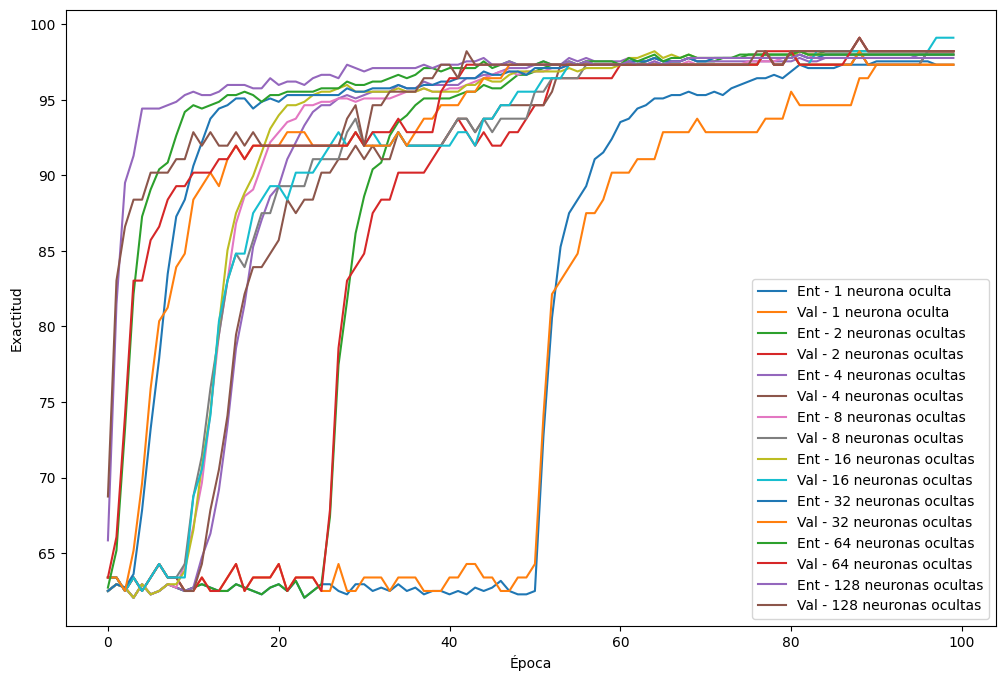

In [444]:
plt.figure(figsize=(12, 8))
plt.plot(range(len(exact_ent_epocas_1)), exact_ent_epocas_1, label='Ent - 1 neurona oculta')
plt.plot(range(len(exact_val_epocas_1)), exact_val_epocas_1, label='Val - 1 neurona oculta')
plt.plot(range(len(exact_ent_epocas_2)), exact_ent_epocas_2, label='Ent - 2 neuronas ocultas')
plt.plot(range(len(exact_val_epocas_2)), exact_val_epocas_2, label='Val - 2 neuronas ocultas')
plt.plot(range(len(exact_ent_epocas_4)), exact_ent_epocas_4, label='Ent - 4 neuronas ocultas')
plt.plot(range(len(exact_val_epocas_4)), exact_val_epocas_4, label='Val - 4 neuronas ocultas')
plt.plot(range(len(exact_ent_epocas_8)), exact_ent_epocas_8, label='Ent - 8 neuronas ocultas')
plt.plot(range(len(exact_val_epocas_8)), exact_val_epocas_8, label='Val - 8 neuronas ocultas')
plt.plot(range(len(exact_ent_epocas_16)), exact_ent_epocas_16, label='Ent - 16 neuronas ocultas')
plt.plot(range(len(exact_val_epocas_16)), exact_val_epocas_16, label='Val - 16 neuronas ocultas')
plt.plot(range(len(exact_ent_epocas_32)), exact_ent_epocas_32, label='Ent - 32 neuronas ocultas')
plt.plot(range(len(exact_val_epocas_32)), exact_val_epocas_32, label='Val - 32 neuronas ocultas')
plt.plot(range(len(exact_ent_epocas_64)), exact_ent_epocas_64, label='Ent - 64 neuronas ocultas')
plt.plot(range(len(exact_val_epocas_64)), exact_val_epocas_64, label='Val - 64 neuronas ocultas')
plt.plot(range(len(exact_ent_epocas_128)), exact_ent_epocas_128, label='Ent - 128 neuronas ocultas')
plt.plot(range(len(exact_val_epocas_128)), exact_val_epocas_128, label='Val - 128 neuronas ocultas')

plt.ylabel('Exactitud')
plt.xlabel('Época')
plt.legend(loc='lower right', fontsize=10)
plt.show()

**Apartado d**

Podemos ver como a mayor número de neuronas ocultas, más rápido evoluciona el rendimiento obteniendo una exactitud mayor más rápidamente, lo cuál tiene sentido, ya que modelos con mayor número de neuronas en la capa oculta tendrán una red con más capacidad para aprender.

#EJERCICIO 4

Implementamos las funciones de MandelbrotFractalClassification.ipynb

In [445]:
# Compute a point of the Mandelbrot fractal
# Inputs:
# a, b = real and imaginary parts of the complex number z_0 = a + b*i that
#        initiates the succession of complex numbers
# Output:
# color_pixel = float between 0 and 1 that indicates how many terms the
#        succession of complex numbers takes to diverge: 0 indicates that it does
#        not diverge before MAX_ITERATIONS terms; 1 indicates that it diverges
#        immediately, i.e. at the second term

# Maximum iterations to check whether the succession of complex numbers diverges
MAX_ITERATIONS = 80

def mandelbrot_point(a,b):
    c = complex(a,b)
    z = 0
    n = 0
    while abs(z) <= 2 and n < MAX_ITERATIONS:
        z = z*z + c
        n += 1
    color_pixel = 1.0 - (n / MAX_ITERATIONS)
    return color_pixel

In [446]:
# Obtain a matrix filled with the color values of the Mandelbrot fractal
# Inputs:
# start_a, end_a, num_a = starting value, ending value, and number of values
#      for the real part of the complex number
#      z_0 = a + b*i that initiates the succession of complex numbers
# start_b, end_b, num_b = starting value, ending value, and number of values
#      for the imaginary part of the complex number
#      z_0 = a + b*i that initiates the succession of complex numbers
# Output:
# matrix = ndarray of shape (num_a, num_b) which contains
#      floats between 0 and 1 that indicate how many terms the
#        succession of complex numbers takes to diverge: 0 indicates that it does
#        not diverge before MAX_ITERATIONS terms; 1 indicates that it diverges
#        immediately, i.e. at the second term
def mandelbrot_matrix(start_a, end_a, num_a, start_b, end_b, num_b):
  values_a = np.linspace(start_a, end_a, num_a)
  values_b = np.linspace(start_b, end_b, num_b)
  matrix = np.zeros((values_a.size, values_b.size))
  for index_a, a in enumerate(values_a):
      for index_b, b in enumerate(values_b):
          matrix[index_a, index_b] = mandelbrot_point(a, b)
  return matrix

In [447]:
# Obtain a binary classification dataset based on the Mandelbrot fractal
# Inputs:
# start_a, end_a = starting value and ending value
#      for the real part of the complex number
#      z_0 = a + b*i that initiates the succession of complex numbers
# start_b, end_b = starting value and ending value
#      for the imaginary part of the complex number
#      z_0 = a + b*i that initiates the succession of complex numbers
# num_samples = number of samples to obtain
# Output:
# matrix = ndarray of shape (num_samples, 2) which contains
#      floats between 0 and 1 that indicate how many terms the
#        succession of complex numbers takes to diverge: 0 indicates that it does
#        not diverge before MAX_ITERATIONS terms; 1 indicates that it diverges
#        immediately, i.e. at the second term
def mandelbrot_classification(start_a, end_a, start_b, end_b, num_samples):
  input_values = np.zeros((num_samples, 2))
  input_values[:, 0] = np.random.uniform(start_a, end_a, size=(num_samples,) )
  input_values[:, 1] = np.random.uniform(start_b, end_b, size=(num_samples,) )
  output_values = np.zeros((num_samples, ), dtype=np.int32)
  for ndx in range(num_samples):
    output_values[ndx] = mandelbrot_point(input_values[ndx, 0], input_values[ndx, 1]) > 0.5
  return input_values, output_values

**Apartado a**

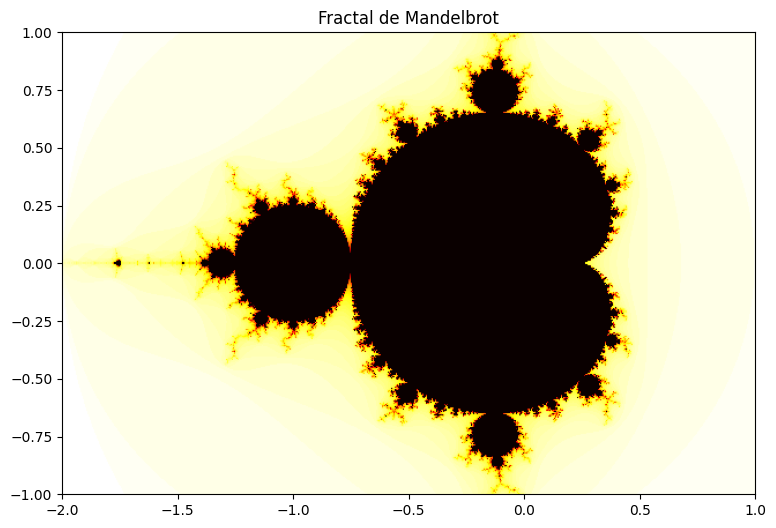

In [448]:
start_a, end_a, num_a = -2, 1, 600
start_b, end_b, num_b = -1, 1, 400
fractal_matrix = mandelbrot_matrix(start_a, end_a, num_a, start_b, end_b, num_b)

plt.figure(figsize=(10, 6))
plt.imshow(fractal_matrix.T, cmap='hot', extent=[start_a, end_a, start_b, end_b])
plt.title('Fractal de Mandelbrot')
plt.show()

**Apartado b**

In [449]:
num_samples = 10000  #Número razonable de muestras para clasificación
X, y = mandelbrot_classification(start_a, end_a, start_b, end_b, num_samples)

In [450]:
scaler = StandardScaler()
X_std = scaler.fit_transform(X)

In [451]:
X_ent, X_val, y_ent, y_val = train_test_split(X_std, y, test_size=0.2, stratify=y, random_state=10)

**Apartado c**

In [454]:
num_ocultas_4 = [4, 8, 12, 16, 20, 24, 28, 32]

for n in num_ocultas_4:
    globals()[f'redMLP4_{n}'] = RedMulticapa(num_rasgos=2,
                                            num_ocultas=n,
                                            num_clases=2)

In [455]:
np.random.seed(10)
ecm_ent_epoca4, exact_ent_epoca4, exact_val_epoca4 = redMLP4_4.entrenar(
    X_ent, y_ent, X_val, y_val, num_epocas=1000, tasa_aprend=0.05, tam_lote=32)

Época: 001/1000 | ECM entrenamiento: 0.20 | Exact entrenamiento: 72.88% | Exact Validación: 72.78%
Época: 002/1000 | ECM entrenamiento: 0.20 | Exact entrenamiento: 72.88% | Exact Validación: 72.78%
Época: 003/1000 | ECM entrenamiento: 0.20 | Exact entrenamiento: 72.88% | Exact Validación: 72.98%
Época: 004/1000 | ECM entrenamiento: 0.20 | Exact entrenamiento: 72.88% | Exact Validación: 72.78%
Época: 005/1000 | ECM entrenamiento: 0.20 | Exact entrenamiento: 72.88% | Exact Validación: 72.93%
Época: 006/1000 | ECM entrenamiento: 0.20 | Exact entrenamiento: 72.88% | Exact Validación: 72.83%
Época: 007/1000 | ECM entrenamiento: 0.20 | Exact entrenamiento: 72.88% | Exact Validación: 72.98%
Época: 008/1000 | ECM entrenamiento: 0.20 | Exact entrenamiento: 72.88% | Exact Validación: 72.98%
Época: 009/1000 | ECM entrenamiento: 0.20 | Exact entrenamiento: 72.88% | Exact Validación: 72.78%
Época: 010/1000 | ECM entrenamiento: 0.20 | Exact entrenamiento: 72.88% | Exact Validación: 72.83%
Época: 011

In [456]:
np.random.seed(10)
ecm_ent_epoca8, exact_ent_epoca8, exact_val_epoca8 = redMLP4_8.entrenar(
    X_ent, y_ent, X_val, y_val, num_epocas=1000, tasa_aprend=0.05, tam_lote=32)

Época: 001/1000 | ECM entrenamiento: 0.20 | Exact entrenamiento: 72.88% | Exact Validación: 72.78%
Época: 002/1000 | ECM entrenamiento: 0.20 | Exact entrenamiento: 72.88% | Exact Validación: 72.78%
Época: 003/1000 | ECM entrenamiento: 0.20 | Exact entrenamiento: 72.88% | Exact Validación: 72.98%
Época: 004/1000 | ECM entrenamiento: 0.20 | Exact entrenamiento: 72.88% | Exact Validación: 72.78%
Época: 005/1000 | ECM entrenamiento: 0.20 | Exact entrenamiento: 72.88% | Exact Validación: 72.93%
Época: 006/1000 | ECM entrenamiento: 0.20 | Exact entrenamiento: 72.88% | Exact Validación: 72.83%
Época: 007/1000 | ECM entrenamiento: 0.20 | Exact entrenamiento: 72.88% | Exact Validación: 72.98%
Época: 008/1000 | ECM entrenamiento: 0.20 | Exact entrenamiento: 72.88% | Exact Validación: 72.98%
Época: 009/1000 | ECM entrenamiento: 0.20 | Exact entrenamiento: 72.88% | Exact Validación: 72.78%
Época: 010/1000 | ECM entrenamiento: 0.20 | Exact entrenamiento: 72.88% | Exact Validación: 72.83%
Época: 011

In [457]:
np.random.seed(10)
ecm_ent_epoca16, exact_ent_epoca16, exact_val_epoca16 = redMLP4_16.entrenar(
    X_ent, y_ent, X_val, y_val, num_epocas=1000, tasa_aprend=0.05, tam_lote=32)

Época: 001/1000 | ECM entrenamiento: 0.20 | Exact entrenamiento: 72.88% | Exact Validación: 72.78%
Época: 002/1000 | ECM entrenamiento: 0.20 | Exact entrenamiento: 72.88% | Exact Validación: 72.78%
Época: 003/1000 | ECM entrenamiento: 0.20 | Exact entrenamiento: 72.88% | Exact Validación: 72.98%
Época: 004/1000 | ECM entrenamiento: 0.20 | Exact entrenamiento: 72.88% | Exact Validación: 72.78%
Época: 005/1000 | ECM entrenamiento: 0.20 | Exact entrenamiento: 72.88% | Exact Validación: 72.93%
Época: 006/1000 | ECM entrenamiento: 0.20 | Exact entrenamiento: 72.88% | Exact Validación: 72.83%
Época: 007/1000 | ECM entrenamiento: 0.20 | Exact entrenamiento: 72.88% | Exact Validación: 72.98%
Época: 008/1000 | ECM entrenamiento: 0.20 | Exact entrenamiento: 72.88% | Exact Validación: 72.98%
Época: 009/1000 | ECM entrenamiento: 0.20 | Exact entrenamiento: 72.88% | Exact Validación: 72.78%
Época: 010/1000 | ECM entrenamiento: 0.20 | Exact entrenamiento: 72.88% | Exact Validación: 72.83%
Época: 011

In [458]:
np.random.seed(10)
ecm_ent_epoca20, exact_ent_epoca20, exact_val_epoca20 = redMLP4_20.entrenar(
    X_ent, y_ent, X_val, y_val, num_epocas=1000, tasa_aprend=0.05, tam_lote=32)

Época: 001/1000 | ECM entrenamiento: 0.20 | Exact entrenamiento: 72.88% | Exact Validación: 72.78%
Época: 002/1000 | ECM entrenamiento: 0.20 | Exact entrenamiento: 72.88% | Exact Validación: 72.78%
Época: 003/1000 | ECM entrenamiento: 0.20 | Exact entrenamiento: 72.88% | Exact Validación: 72.98%
Época: 004/1000 | ECM entrenamiento: 0.20 | Exact entrenamiento: 72.88% | Exact Validación: 72.78%
Época: 005/1000 | ECM entrenamiento: 0.20 | Exact entrenamiento: 72.88% | Exact Validación: 72.93%
Época: 006/1000 | ECM entrenamiento: 0.20 | Exact entrenamiento: 72.88% | Exact Validación: 72.83%
Época: 007/1000 | ECM entrenamiento: 0.20 | Exact entrenamiento: 72.88% | Exact Validación: 72.98%
Época: 008/1000 | ECM entrenamiento: 0.20 | Exact entrenamiento: 72.88% | Exact Validación: 72.98%
Época: 009/1000 | ECM entrenamiento: 0.20 | Exact entrenamiento: 72.88% | Exact Validación: 72.78%
Época: 010/1000 | ECM entrenamiento: 0.20 | Exact entrenamiento: 72.88% | Exact Validación: 72.83%
Época: 011

In [459]:
np.random.seed(10)
ecm_ent_epoca24, exact_ent_epoca24, exact_val_epoca24 = redMLP4_24.entrenar(
    X_ent, y_ent, X_val, y_val, num_epocas=1000, tasa_aprend=0.05, tam_lote=32)

Época: 001/1000 | ECM entrenamiento: 0.20 | Exact entrenamiento: 72.88% | Exact Validación: 72.78%
Época: 002/1000 | ECM entrenamiento: 0.20 | Exact entrenamiento: 72.88% | Exact Validación: 72.78%
Época: 003/1000 | ECM entrenamiento: 0.20 | Exact entrenamiento: 72.88% | Exact Validación: 72.98%
Época: 004/1000 | ECM entrenamiento: 0.20 | Exact entrenamiento: 72.88% | Exact Validación: 72.78%
Época: 005/1000 | ECM entrenamiento: 0.20 | Exact entrenamiento: 72.88% | Exact Validación: 72.93%
Época: 006/1000 | ECM entrenamiento: 0.20 | Exact entrenamiento: 72.88% | Exact Validación: 72.83%
Época: 007/1000 | ECM entrenamiento: 0.20 | Exact entrenamiento: 72.88% | Exact Validación: 72.98%
Época: 008/1000 | ECM entrenamiento: 0.20 | Exact entrenamiento: 72.88% | Exact Validación: 72.98%
Época: 009/1000 | ECM entrenamiento: 0.20 | Exact entrenamiento: 72.88% | Exact Validación: 72.78%
Época: 010/1000 | ECM entrenamiento: 0.20 | Exact entrenamiento: 72.88% | Exact Validación: 72.83%
Época: 011

In [460]:
np.random.seed(10)
ecm_ent_epoca28, exact_ent_epoca28, exact_val_epoca28 = redMLP4_28.entrenar(
    X_ent, y_ent, X_val, y_val, num_epocas=1000, tasa_aprend=0.05, tam_lote=32)

Época: 001/1000 | ECM entrenamiento: 0.20 | Exact entrenamiento: 72.88% | Exact Validación: 72.78%
Época: 002/1000 | ECM entrenamiento: 0.20 | Exact entrenamiento: 72.88% | Exact Validación: 72.78%
Época: 003/1000 | ECM entrenamiento: 0.20 | Exact entrenamiento: 72.88% | Exact Validación: 72.98%
Época: 004/1000 | ECM entrenamiento: 0.20 | Exact entrenamiento: 72.88% | Exact Validación: 72.78%
Época: 005/1000 | ECM entrenamiento: 0.20 | Exact entrenamiento: 72.88% | Exact Validación: 72.93%
Época: 006/1000 | ECM entrenamiento: 0.20 | Exact entrenamiento: 72.88% | Exact Validación: 72.83%
Época: 007/1000 | ECM entrenamiento: 0.20 | Exact entrenamiento: 72.88% | Exact Validación: 72.98%
Época: 008/1000 | ECM entrenamiento: 0.20 | Exact entrenamiento: 72.88% | Exact Validación: 72.98%
Época: 009/1000 | ECM entrenamiento: 0.20 | Exact entrenamiento: 72.88% | Exact Validación: 72.78%
Época: 010/1000 | ECM entrenamiento: 0.20 | Exact entrenamiento: 72.88% | Exact Validación: 72.83%
Época: 011

In [461]:
np.random.seed(10)
ecm_ent_epoca32, exact_ent_epoca32, exact_val_epoca32 = redMLP4_32.entrenar(
    X_ent, y_ent, X_val, y_val, num_epocas=1000, tasa_aprend=0.05, tam_lote=32)

Época: 001/1000 | ECM entrenamiento: 0.20 | Exact entrenamiento: 72.88% | Exact Validación: 72.78%
Época: 002/1000 | ECM entrenamiento: 0.20 | Exact entrenamiento: 72.88% | Exact Validación: 72.78%
Época: 003/1000 | ECM entrenamiento: 0.20 | Exact entrenamiento: 72.88% | Exact Validación: 72.98%
Época: 004/1000 | ECM entrenamiento: 0.20 | Exact entrenamiento: 72.88% | Exact Validación: 72.78%
Época: 005/1000 | ECM entrenamiento: 0.20 | Exact entrenamiento: 72.88% | Exact Validación: 72.93%
Época: 006/1000 | ECM entrenamiento: 0.20 | Exact entrenamiento: 72.88% | Exact Validación: 72.83%
Época: 007/1000 | ECM entrenamiento: 0.20 | Exact entrenamiento: 72.88% | Exact Validación: 72.98%
Época: 008/1000 | ECM entrenamiento: 0.20 | Exact entrenamiento: 72.88% | Exact Validación: 72.98%
Época: 009/1000 | ECM entrenamiento: 0.20 | Exact entrenamiento: 72.88% | Exact Validación: 72.78%
Época: 010/1000 | ECM entrenamiento: 0.20 | Exact entrenamiento: 72.88% | Exact Validación: 72.83%
Época: 011

**Apartado d**

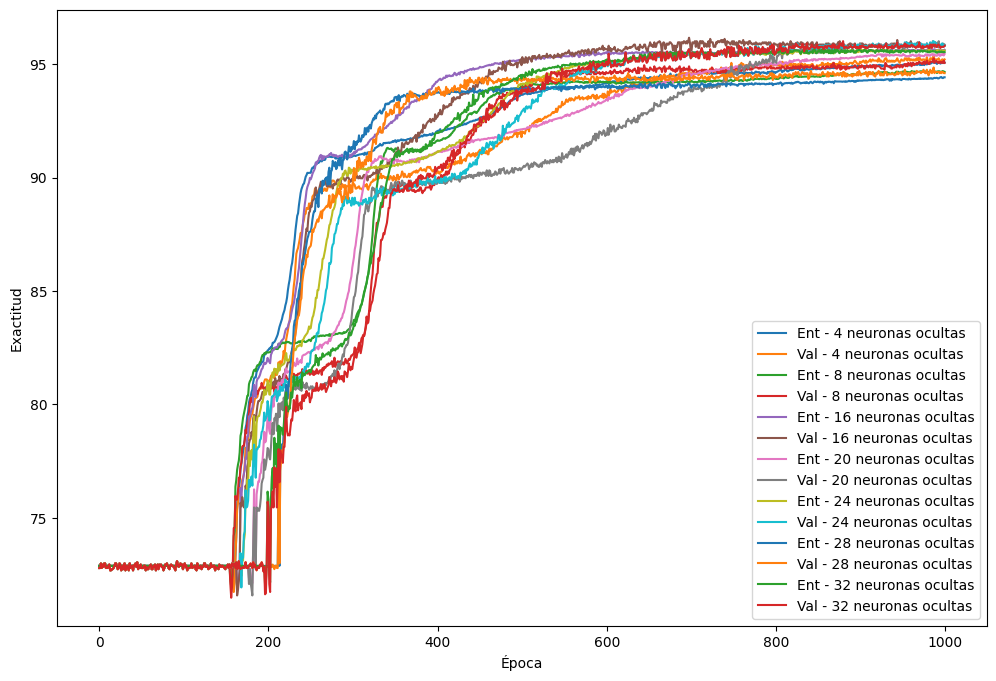

In [462]:
plt.figure(figsize=(12, 8))
plt.plot(range(len(exact_ent_epoca4)), exact_ent_epoca4, label='Ent - 4 neuronas ocultas')
plt.plot(range(len(exact_val_epoca4)), exact_val_epoca4, label='Val - 4 neuronas ocultas')
plt.plot(range(len(exact_ent_epoca8)), exact_ent_epoca8, label='Ent - 8 neuronas ocultas')
plt.plot(range(len(exact_val_epoca8)), exact_val_epoca8, label='Val - 8 neuronas ocultas')
plt.plot(range(len(exact_ent_epoca16)), exact_ent_epoca16, label='Ent - 16 neuronas ocultas')
plt.plot(range(len(exact_val_epoca16)), exact_val_epoca16, label='Val - 16 neuronas ocultas')
plt.plot(range(len(exact_ent_epoca20)), exact_ent_epoca20, label='Ent - 20 neuronas ocultas')
plt.plot(range(len(exact_val_epoca20)), exact_val_epoca20, label='Val - 20 neuronas ocultas')
plt.plot(range(len(exact_ent_epoca24)), exact_ent_epoca24, label='Ent - 24 neuronas ocultas')
plt.plot(range(len(exact_val_epoca24)), exact_val_epoca24, label='Val - 24 neuronas ocultas')
plt.plot(range(len(exact_ent_epoca28)), exact_ent_epoca28, label='Ent - 28 neuronas ocultas')
plt.plot(range(len(exact_val_epoca28)), exact_val_epoca28, label='Val - 28 neuronas ocultas')
plt.plot(range(len(exact_ent_epoca32)), exact_ent_epoca32, label='Ent - 32 neuronas ocultas')
plt.plot(range(len(exact_val_epoca32)), exact_val_epoca32, label='Val - 32 neuronas ocultas')

plt.ylabel('Exactitud')
plt.xlabel('Época')
plt.legend(loc='lower right', fontsize=10)
plt.show()

**Apartado e**

En general, como hemos visto anteriormente, a mayor número de neuronas ocultas, más rápido converge el modelo.